# Task 5: Diffusion Model for MNIST

This notebook implements a simple conditional diffusion-style model for MNIST and gives you material to compare it with your CGAN from Task 3.

What this notebook includes:
- MNIST loading and visualization
- A compact conditional U-Net-like denoiser
- Forward diffusion and reverse sampling
- Training loop
- Sampling conditioned on digits 0-9
- Comparison notes: CGAN vs diffusion


## 1. Imports and setup


In [1]:

import math
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cpu


## 2. Hyperparameters


In [2]:

batch_size = 128
lr = 2e-4
epochs = 10
image_size = 28
channels = 1
num_classes = 10
noise_steps = 200
beta_start = 1e-4
beta_end = 0.02
embed_dim = 64
sample_grid_n = 10


## 3. Dataset


In [3]:

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./MNIST', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, drop_last=True)

print('Train size:', len(train_dataset))
print('Batches per epoch:', len(train_loader))


100%|██████████| 9.91M/9.91M [00:04<00:00, 2.38MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 261kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.09MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.54MB/s]

Train size: 60000
Batches per epoch: 468


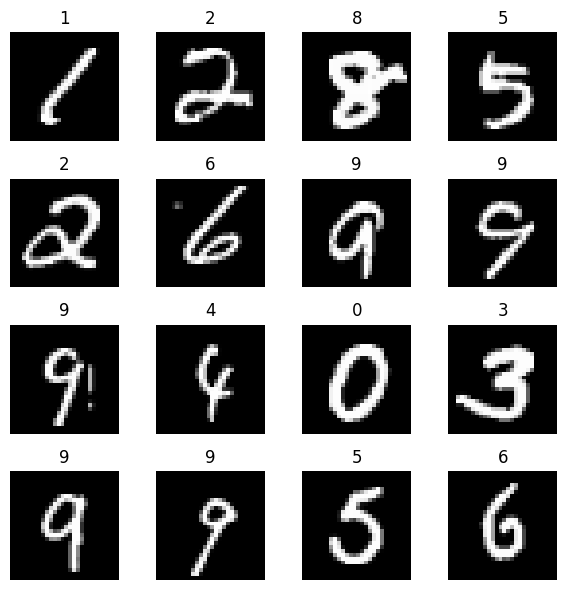

In [4]:

def show_batch(images, labels, n=16):
    images = images[:n]
    labels = labels[:n]
    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for ax, img, lab in zip(axes.flatten(), images, labels):
        ax.imshow(img.squeeze().cpu(), cmap='gray')
        ax.set_title(str(int(lab)))
        ax.axis('off')
    plt.tight_layout()
    plt.show()

x, y = next(iter(train_loader))
show_batch((x * 0.5 + 0.5), y)


## 4. Diffusion schedule


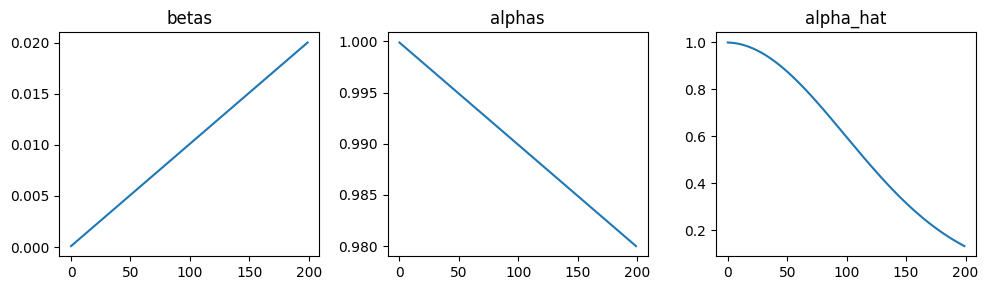

In [5]:

def linear_beta_schedule(steps, beta_start=1e-4, beta_end=0.02):
    return torch.linspace(beta_start, beta_end, steps)

betas = linear_beta_schedule(noise_steps, beta_start, beta_end).to(device)
alphas = 1.0 - betas
alpha_hat = torch.cumprod(alphas, dim=0)

sqrt_alpha_hat = torch.sqrt(alpha_hat)
sqrt_one_minus_alpha_hat = torch.sqrt(1 - alpha_hat)

plt.figure(figsize=(10, 3))
plt.subplot(1, 3, 1)
plt.plot(betas.cpu().numpy())
plt.title('betas')
plt.subplot(1, 3, 2)
plt.plot(alphas.cpu().numpy())
plt.title('alphas')
plt.subplot(1, 3, 3)
plt.plot(alpha_hat.cpu().numpy())
plt.title('alpha_hat')
plt.tight_layout()
plt.show()


## 5. Forward diffusion helper


In [6]:

def sample_timesteps(n):
    return torch.randint(low=0, high=noise_steps, size=(n,), device=device)

def noise_images(x, t):
    sqrt_alpha_hat_t = sqrt_alpha_hat[t][:, None, None, None]
    sqrt_one_minus_alpha_hat_t = sqrt_one_minus_alpha_hat[t][:, None, None, None]
    eps = torch.randn_like(x)
    return sqrt_alpha_hat_t * x + sqrt_one_minus_alpha_hat_t * eps, eps


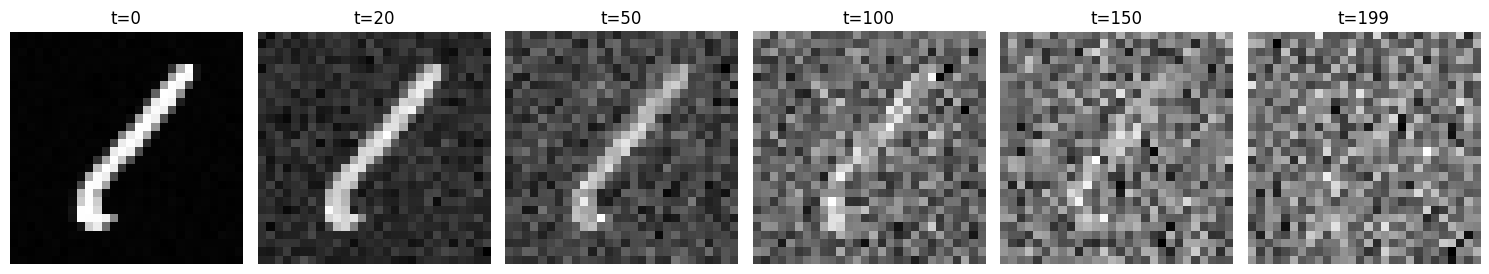

In [7]:

example_img = x[:1].to(device)
steps_to_show = [0, 20, 50, 100, 150, 199]
fig, axes = plt.subplots(1, len(steps_to_show), figsize=(15, 3))
for ax, t in zip(axes, steps_to_show):
    tt = torch.tensor([t], device=device)
    noisy, _ = noise_images(example_img, tt)
    ax.imshow(((noisy[0].detach().cpu() * 0.5) + 0.5).squeeze(), cmap='gray')
    ax.set_title(f't={t}')
    ax.axis('off')
plt.tight_layout()
plt.show()


## 6. Time and label embeddings


In [8]:

class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half_dim = self.dim // 2
        emb_scale = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb_scale)
        emb = t.float()[:, None] * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=1)
        return emb


## 7. Conditional denoiser


In [9]:

class ConditionalDenoiser(nn.Module):
    def __init__(self, img_channels=1, num_classes=10, time_dim=64):
        super().__init__()
        self.time_embed = nn.Sequential(
            SinusoidalPosEmb(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.ReLU()
        )
        self.label_embed = nn.Embedding(num_classes, time_dim)

        self.conv1 = nn.Conv2d(img_channels, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, stride=2, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, stride=2, padding=1)

        self.to_mid = nn.Linear(time_dim, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1)
        self.up2 = nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1)
        self.out = nn.Conv2d(32, img_channels, 3, padding=1)

        self.act = nn.ReLU()

    def forward(self, x, t, y):
        t_emb = self.time_embed(t)
        y_emb = self.label_embed(y)
        cond = t_emb + y_emb

        h1 = self.act(self.conv1(x))
        h2 = self.act(self.conv2(h1))
        h3 = self.act(self.conv3(h2))

        cond_map = self.to_mid(cond)[:, :, None, None]
        h3 = h3 + cond_map

        u1 = self.act(self.up1(h3))
        u2 = self.act(self.up2(u1))
        out = self.out(u2)
        return out

model = ConditionalDenoiser(img_channels=channels, num_classes=num_classes, time_dim=embed_dim).to(device)
print('Parameters:', sum(p.numel() for p in model.parameters()))


Parameters: 270017


## 8. Training setup


In [10]:

optimizer = torch.optim.Adam(model.parameters(), lr=lr)
loss_fn = nn.MSELoss()


## 9. Training loop


In [ ]:

loss_history = []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        t = sample_timesteps(imgs.shape[0])
        x_t, noise = noise_images(imgs, t)
        predicted_noise = model(x_t, t, labels)
        loss = loss_fn(predicted_noise, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f'Epoch {epoch+1}/{epochs} - loss: {avg_loss:.4f}')


Epoch 1/10 - loss: 0.4273
Epoch 2/10 - loss: 0.1968


In [ ]:

plt.figure(figsize=(6, 4))
plt.plot(loss_history, marker='o')
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.grid(True, alpha=0.3)
plt.show()


## 10. Reverse sampling


In [ ]:

@torch.no_grad()
def sample(model, labels, n=None):
    model.eval()
    if n is None:
        n = len(labels)
    x = torch.randn((n, 1, image_size, image_size), device=device)
    labels = labels.to(device)

    for i in reversed(range(noise_steps)):
        t = torch.full((n,), i, device=device, dtype=torch.long)
        predicted_noise = model(x, t, labels)

        alpha = alphas[t][:, None, None, None]
        alpha_hat_t = alpha_hat[t][:, None, None, None]
        beta = betas[t][:, None, None, None]

        if i > 0:
            noise = torch.randn_like(x)
        else:
            noise = torch.zeros_like(x)

        x = (1 / torch.sqrt(alpha)) * (x - ((1 - alpha) / torch.sqrt(1 - alpha_hat_t)) * predicted_noise) + torch.sqrt(beta) * noise

    x = x.clamp(-1, 1)
    return x


## 11. Generate one sample per digit


In [ ]:

labels = torch.arange(0, 10)
samples = sample(model, labels, n=10)
samples = (samples * 0.5) + 0.5

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, ax in enumerate(axes):
    ax.imshow(samples[i].detach().cpu().squeeze(), cmap='gray')
    ax.set_title(str(i))
    ax.axis('off')
plt.tight_layout()
plt.show()


## 12. Generate multiple conditioned samples


In [ ]:

labels = torch.tensor([0,1,2,3,4,5,6,7,8,9] * 2)
samples = sample(model, labels, n=len(labels))
samples = (samples * 0.5) + 0.5

fig, axes = plt.subplots(4, 5, figsize=(8, 6))
for ax, img, lab in zip(axes.flatten(), samples, labels):
    ax.imshow(img.detach().cpu().squeeze(), cmap='gray')
    ax.set_title(str(int(lab)))
    ax.axis('off')
plt.tight_layout()
plt.show()


## 13. Save the trained model


In [ ]:

os.makedirs('checkpoints', exist_ok=True)
torch.save({
    'model_state_dict': model.state_dict(),
    'loss_history': loss_history,
    'noise_steps': noise_steps
}, 'checkpoints/task5_diffusion_mnist.pt')
print('Saved to checkpoints/task5_diffusion_mnist.pt')


## 14. Discussion: CGAN vs diffusion

Use these points in your report:

### Main difference in generation process
- GAN generates an image in one forward pass from random noise.
- Diffusion starts from noise and gradually denoises over many steps.

### Training objective
- GAN uses adversarial training between generator and discriminator.
- Diffusion trains a denoiser to predict the noise added to the image.

### Stability
- GAN training can be unstable and may suffer from mode collapse.
- Diffusion is usually more stable because it uses a direct supervised loss.

### Speed
- GAN sampling is fast.
- Diffusion sampling is slower because it needs many denoising steps.

### Output quality
- Diffusion often gives better diversity and smoother training.
- GAN may be faster but can miss modes or produce unstable results.
